# 1- Project Overview
The purpose of this notebook is to explore the cleaned power plant dataset, identify relationships between environmental variables and electrical power output, and generate business insights that support operational decision-making.

# 2- Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Status update
print("DONE")

DONE


In [2]:
# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# Status update
print("DONE")

DONE


# 3- Load Clean Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zahraatouq/cpp-dataset/clean_power_plant_data.csv")

df.head()

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Power_Output
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


# 4- Understanding the Dataset

# 4.1- What does the dataset look loke after cleaning 

In [4]:
df.shape

(9527, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ambient_Temperature  9527 non-null   float64
 1   Exhaust_Vacuum       9527 non-null   float64
 2   Ambient_Pressure     9527 non-null   float64
 3   Relative_Humidity    9527 non-null   float64
 4   Power_Output         9527 non-null   float64
dtypes: float64(5)
memory usage: 372.3 KB


In [6]:
df.describe()

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Power_Output
count,9527.000000,9527.000000,9527.000000,9527.000000,9527.00000
mean,19.658225,54.293421,1013.237084,73.334951,454.33591
std,7.444397,12.686309,5.940526,14.607513,17.03908
min,1.810000,25.360000,992.890000,25.560000,420.26000
25%,13.530000,41.740000,1009.085000,63.375000,439.75000
50%,20.350000,52.080000,1012.920000,75.000000,451.52000
75%,25.710000,66.510000,1017.200000,84.850000,468.36500
max,37.110000,81.560000,1033.300000,100.160000,495.76000


## Observation

The cleaned dataset contains 9,527 observations and five continuous numerical variables collected from a Combined Cycle Power Plant. All features are stored as numerical float values with no missing records remaining after the data preparation stage.

The statistical summary shows that all variables fall within the expected operational ranges. The Power Output variable ranges between 420.26 MW and 495.76 MW, while environmental variables such as temperature, pressure, humidity, and exhaust vacuum show realistic operating conditions.

The dataset demonstrates good quality and consistency, making it suitable for further exploratory analysis to investigate relationships between environmental factors and power generation performance.

# 4.2- How is Power Output distributed? 

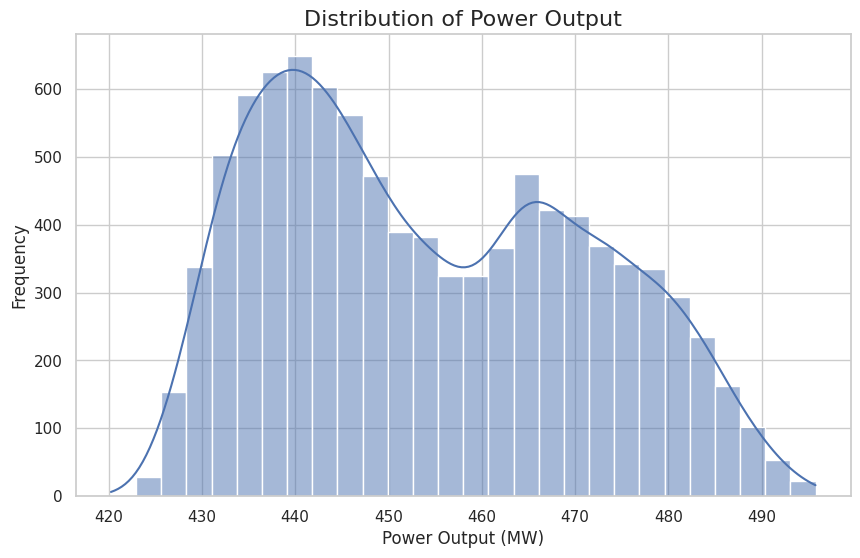

In [7]:
sns.histplot(
    data=df,
    x="Power_Output",
    kde=True
)

plt.title("Distribution of Power Output")
plt.xlabel("Power Output (MW)")
plt.ylabel("Frequency")

plt.show()

## Observation

The Power Output distribution shows a non-uniform pattern with two noticeable peaks, indicating that the plant frequently operates within two common production ranges. The primary concentration of observations appears around 435 – 440 MW, while a secondary peak is observed around 465 MW.

The presence of multiple peaks suggests that the power plant may experience different operating conditions or performance levels. However, additional operational information would be required to determine the exact causes behind these patterns.

The overall power output ranges from approximately 420 MW to 496 MW, showing variation in electricity generation levels across different operating conditions.

## Business Interpretation

Understanding the distribution of power output helps identify common operating ranges and detect unusual production patterns. These insights can support performance monitoring by highlighting normal production behavior and potential deviations that may require further investigation.

# 4.3-How Does Ambient Temperature Affect Power Output?

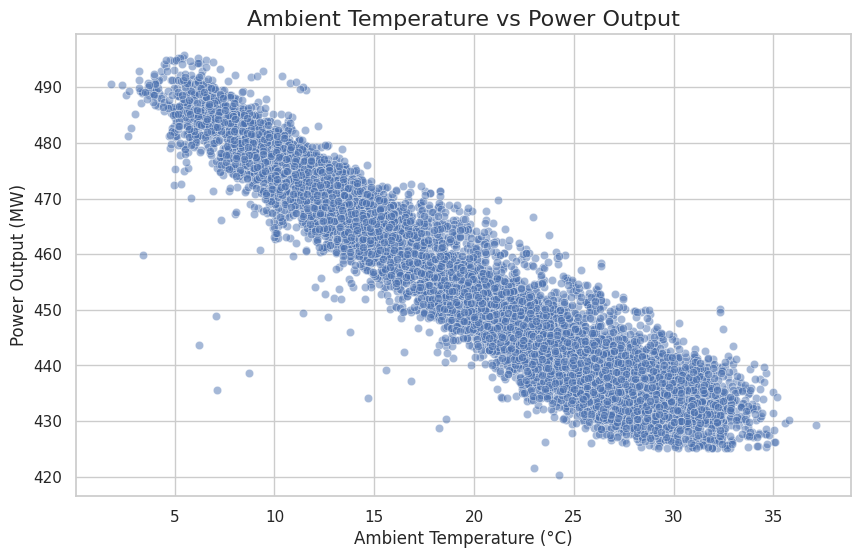

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Ambient_Temperature",
    y="Power_Output",
    alpha=0.5
)

plt.title("Ambient Temperature vs Power Output")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Power Output (MW)")

plt.show()

## Observation

The scatter plot reveals a strong negative relationship between ambient temperature and power output. As the ambient temperature increases, the electrical power output consistently decreases.

The highest power generation values are observed at lower temperatures (approximately 5–10°C), where the plant frequently produces close to 490 MW. In contrast, power output declines noticeably when temperatures exceed 30°C, with most observations falling between 425 MW and 440 MW.

Although a few observations deviate slightly from the overall trend, the relationship remains highly consistent across the dataset.

## Business Interpretation

Recognizing the impact of ambient temperature allows plant operators to better forecast power generation, optimize operating conditions, and improve resource planning during warmer periods when production efficiency naturally declines.

# 4.4- How Does Exhaust Vacuum Affect Power Output?

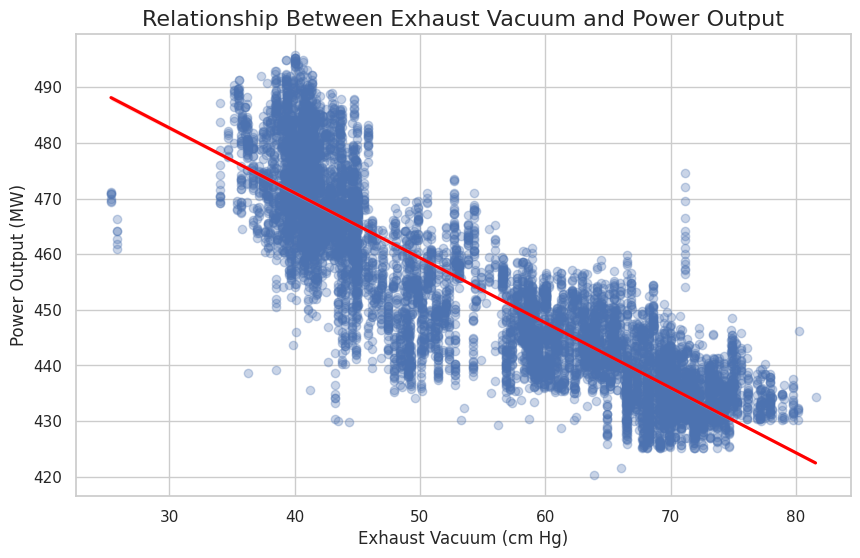

In [9]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Exhaust_Vacuum",
    y="Power_Output",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Exhaust Vacuum and Power Output")
plt.xlabel("Exhaust Vacuum (cm Hg)")
plt.ylabel("Power Output (MW)")

plt.show()

## Observation

The relationship between Exhaust Vacuum and Power Output is generally negative. As exhaust vacuum increases, electrical power output tends to decrease.

Higher power generation is typically observed at lower exhaust vacuum values, while lower power output becomes more common as exhaust vacuum exceeds approximately 70 cm Hg. Although the overall trend is clear, the data exhibits several dense clusters and a greater spread compared to the temperature relationship, suggesting that additional operating factors may also influence power generation.

## Business Interpretation

Exhaust vacuum appears to be an important operational variable associated with plant performance. Monitoring vacuum conditions could help operators identify efficiency changes and detect operating states that may lead to reduced electrical output.

Tracking exhaust vacuum can support predictive maintenance and operational monitoring by identifying conditions that are associated with lower power generation efficiency.

# 4.5- How Does Ambient Pressure Affect Power Output?

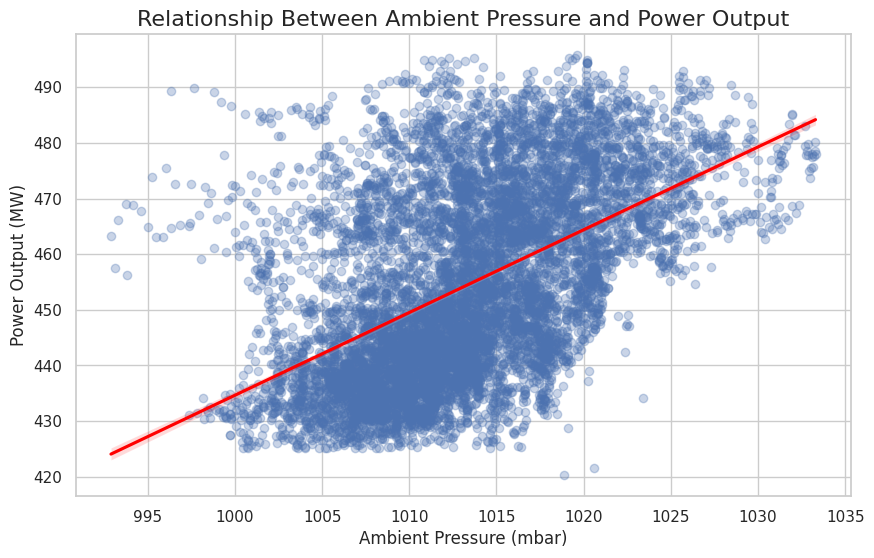

In [10]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Ambient_Pressure",
    y="Power_Output",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Ambient Pressure and Power Output")
plt.xlabel("Ambient Pressure (mbar)")
plt.ylabel("Power Output (MW)")

plt.show()

## Observation

The scatter plot suggests a positive relationship between ambient pressure and power output. As ambient pressure increases, the overall trend indicates a gradual increase in electrical power generation.

Higher power output values are generally observed under higher atmospheric pressure conditions, while lower pressure levels are associated with lower power generation. However, the data exhibits considerable variability around the trend line, suggesting that ambient pressure alone does not fully explain changes in power output.

## Business Interpretation

Ambient pressure appears to contribute positively to plant performance. Nevertheless, the relatively wide spread of observations indicates that pressure should be considered alongside other environmental variables rather than as an independent predictor of power generation.

Understanding the influence of atmospheric pressure can improve operational forecasting and provides additional context when analyzing plant efficiency under varying environmental conditions.

# 4.6- How Does Relative Humidity Affect Power Output?

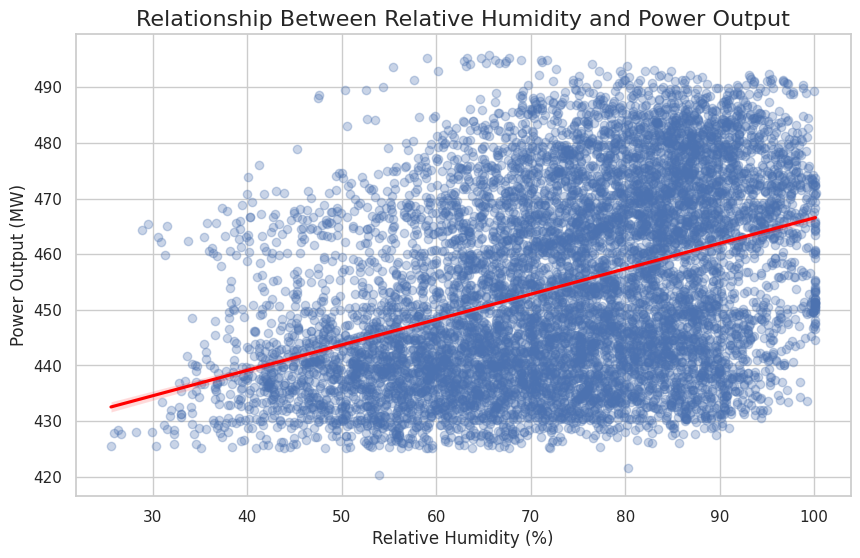

In [11]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Relative_Humidity",
    y="Power_Output",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Relative Humidity and Power Output")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Power Output (MW)")

plt.show()

## Observation

The relationship between relative humidity and power output appears to be weak compared with the other environmental variables. Although the regression line shows a slight positive trend, the observations are widely scattered across different humidity levels, indicating that humidity alone does not strongly explain variations in power generation.

Most observations are concentrated at humidity levels above 60%, with power output showing a wide range across these conditions. This suggests that relative humidity may have a secondary influence on plant performance when compared with other operational factors.

## Business Interpretation

Relative humidity appears to have a limited direct relationship with electrical power output. Therefore, it should be considered as part of a combined analysis with other environmental variables rather than as an individual driver of plant performance.

# 5- Correlation Analysis

In [12]:
corr = df.corr()

corr["Power_Output"].sort_values(ascending=False)

Power_Output           1.000000
Ambient_Pressure       0.518687
Relative_Humidity      0.391175
Exhaust_Vacuum        -0.869900
Ambient_Temperature   -0.947908
Name: Power_Output, dtype: float64

## Observation

The correlation analysis confirms the patterns observed during the individual feature analysis.

Ambient Temperature shows the strongest relationship with Power Output, with a strong negative correlation of -0.95, indicating that higher temperatures are strongly associated with reduced electrical generation.

Exhaust Vacuum also demonstrates a strong negative relationship with Power Output, with a correlation of -0.87.

Ambient Pressure shows a moderate positive correlation of 0.52, while Relative Humidity has a weaker positive correlation of 0.39, suggesting that these variables have a smaller individual impact on power generation compared with temperature and exhaust vacuum.

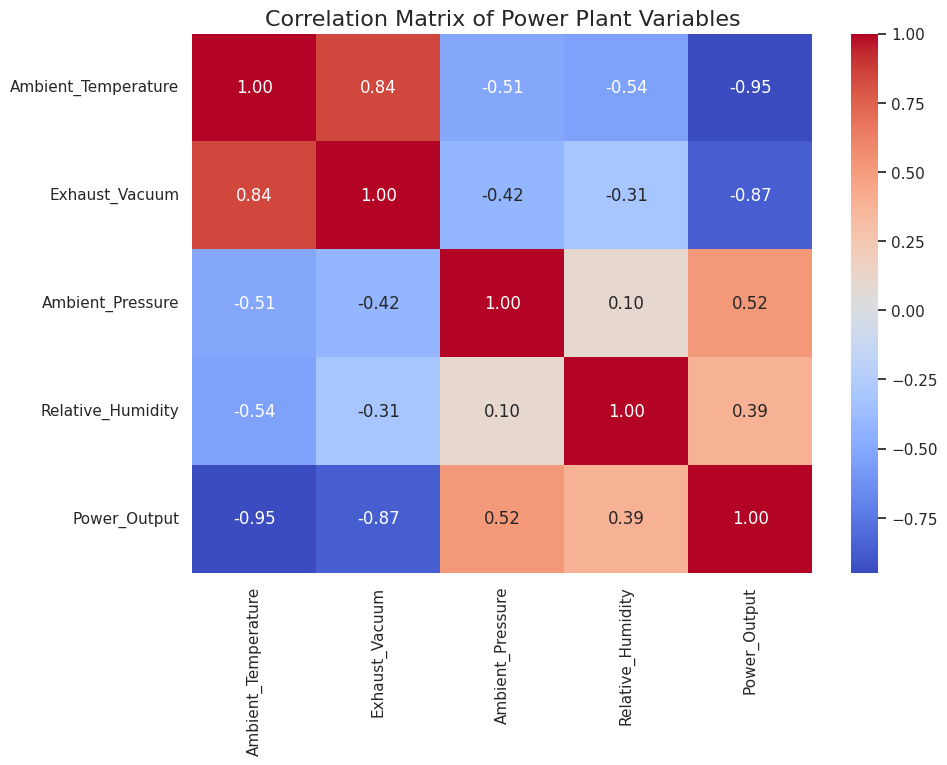

In [13]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Power Plant Variables")

plt.show()

## Observation

The correlation matrix confirms the relationships identified during the previous exploratory analysis.

Ambient Temperature has the strongest negative correlation with Power Output (-0.95), indicating that higher temperatures are strongly associated with reduced electricity generation.

Exhaust Vacuum also shows a strong negative correlation with Power Output (-0.87), making it another important operational variable associated with plant performance.

Ambient Pressure demonstrates a moderate positive correlation (0.52), while Relative Humidity shows a weaker positive correlation (0.39), suggesting that these variables have a smaller individual relationship with power output.

Additionally, Ambient Temperature and Exhaust Vacuum show a strong positive correlation (0.84), indicating that these two operating variables tend to change together within the dataset.

## Business Interpretation

The correlation analysis highlights that environmental conditions, particularly ambient temperature and exhaust vacuum, are strongly associated with changes in power generation. These variables should receive greater attention when monitoring plant efficiency and developing predictive models.

However, correlation alone does not determine actual feature importance or causation. Further analysis using machine learning techniques will be required to evaluate the predictive contribution of each variable.

# 6- Multivariate Analysis

## Pairplot Analysis

<Figure size 1200x1000 with 0 Axes>

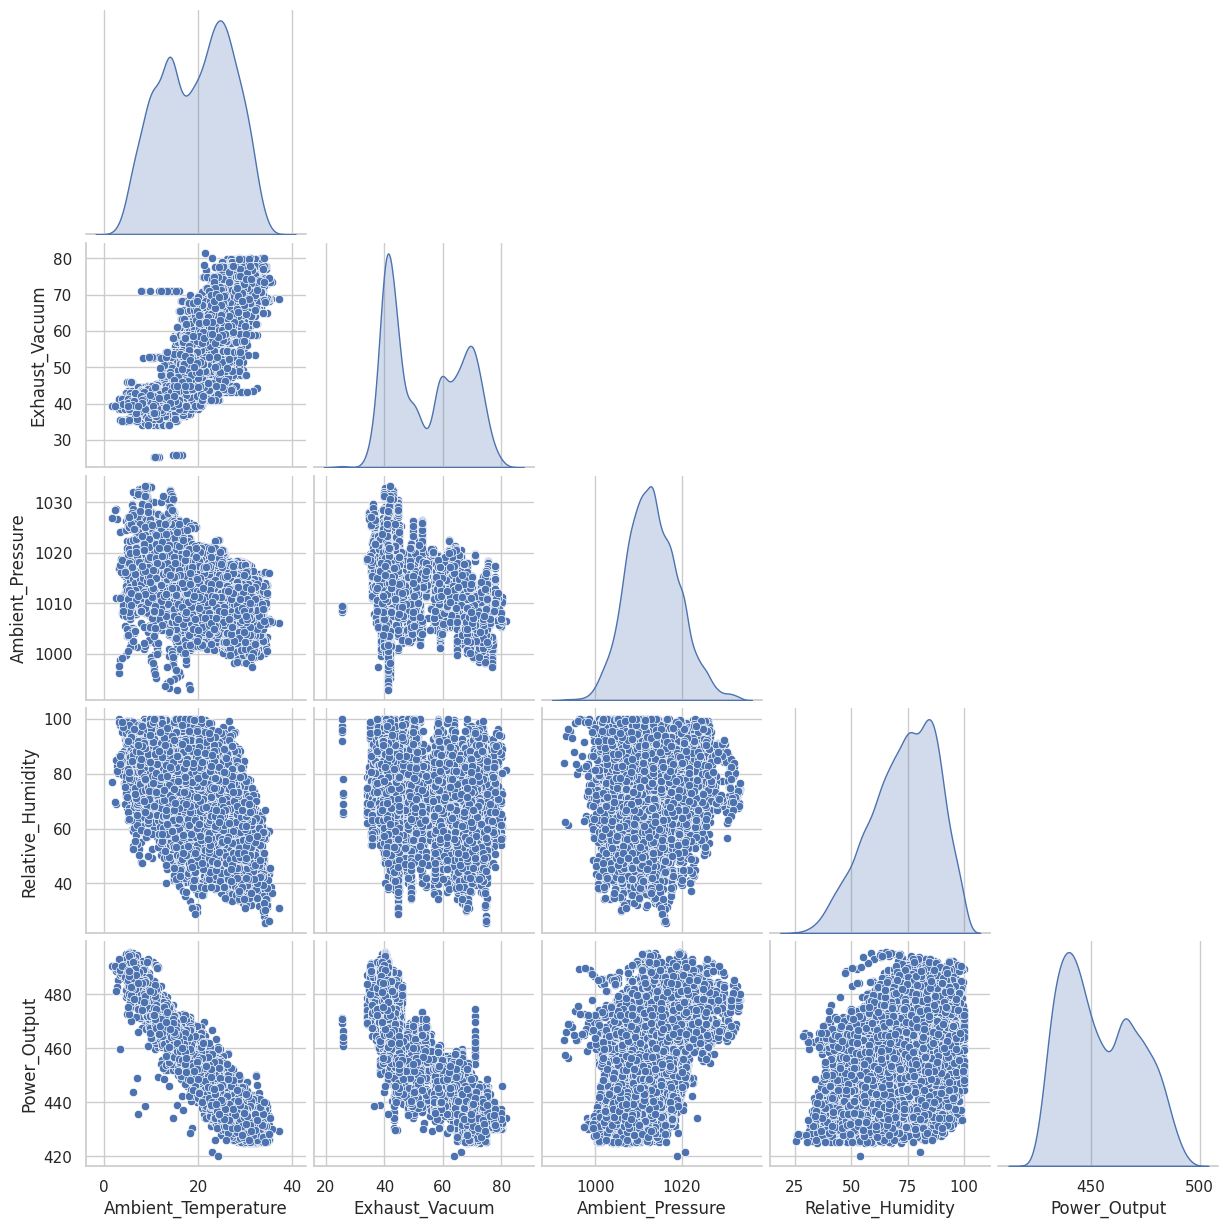

In [14]:
plt.figure(figsize=(12,10))

sns.pairplot(
    df,
    diag_kind="kde",
    corner=True
)

plt.show()

## Observation

The pairplot analysis provides a comprehensive view of the relationships between all variables and confirms the patterns identified in the previous analyses.

The diagonal distributions show that some variables, such as Power Output and Ambient Temperature, exhibit multi-modal patterns, suggesting the presence of different operating conditions within the dataset. Exhaust Vacuum also shows multiple concentration areas, indicating variations in plant operating states.

The relationship plots confirm the strong negative association between Ambient Temperature and Power Output, as well as between Exhaust Vacuum and Power Output. These relationships appear as clear downward trends with relatively limited scatter.

Ambient Pressure shows a moderate positive relationship with Power Output but with wider variability, while Relative Humidity demonstrates a weaker and more scattered relationship.

## Business Interpretation

The multivariate analysis confirms that power generation is influenced by multiple environmental factors rather than a single variable. Temperature and exhaust vacuum appear to be the dominant variables associated with changes in plant output, while pressure and humidity provide additional but weaker information.

The observed patterns suggest that combining multiple environmental variables will likely provide better predictive performance than analyzing each factor independently.

# 7- Key Insights

The exploratory data analysis revealed that power generation performance is strongly associated with environmental operating conditions. Ambient Temperature showed the strongest negative relationship with Power Output, indicating that higher temperatures are consistently linked with reduced electricity generation efficiency. Exhaust Vacuum also demonstrated a strong negative relationship, highlighting its importance as an operational factor affecting plant performance. In comparison, Ambient Pressure showed a moderate positive relationship, while Relative Humidity had the weakest association with power output, suggesting a smaller individual contribution. Overall, the analysis indicates that power generation is influenced by a combination of environmental variables rather than a single factor. These findings provide a strong foundation for developing predictive machine learning models capable of estimating plant output and supporting data-driven operational decisions.